# 🛒 E-Commerce Customer Retention, Churn Analysis & CLV Dashboard

**Portfolio Project | Data Analyst / Business Analyst**

---

## Business Objective

Answer six core business questions using 5 interconnected datasets:

1. 🏆 Who are the most valuable customers?
2. ⚠️  Which customers are likely to churn?
3. 🔗 What factors impact customer retention?
4. 💰 Which products generate maximum revenue?
5. 📈 What is Customer Lifetime Value (CLV)?
6. 📊 What is the monthly retention rate?

---

## Datasets
| File | Rows | Description |
|------|------|-------------|
| customers.csv | 2,000 | Demographics & registration |
| orders.csv | 8,500 | All purchase transactions |
| products.csv | 150 | Product catalogue |
| payments.csv | ~7,000 | Payment records |
| reviews.csv | ~3,800 | Customer reviews & ratings |

## 0. Setup & Imports

In [2]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Image

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from scipy import stats

# Project modules
from data_loading import load_all, print_summary
from data_cleaning import clean_all, print_quality_report, print_cleaning_summary
from feature_engineering import build_customer_features, print_feature_summary
from customer_segmentation import segment_customers, print_segmentation_results
from churn_analysis import (
    train_churn_model, evaluate_model, get_feature_importance,
    correlation_analysis, hypothesis_test, print_churn_results
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

CHARTS_DIR = os.path.join('..', 'dashboard', 'charts')

print('✅ All imports successful!')

✅ All imports successful!


## 1. Data Loading

In [3]:
bundle = load_all()
print_summary(bundle)

customers = bundle['customers']
orders    = bundle['orders']
products  = bundle['products']
payments  = bundle['payments']
reviews   = bundle['reviews']

# Quick peek
display(customers.head(3))
display(orders.head(3))


     E-COMMERCE CUSTOMER ANALYTICS PLATFORM
Dataset loaded successfully

  Customers   :  2,000 rows  ×  14 cols
  Orders      :  8,500 rows  ×  13 cols
  Products    :    150 rows  ×  10 cols
  Payments    :  6,958 rows  ×  8 cols
  Reviews     :  3,827 rows  ×  8 cols



,customer_id,first_name,last_name,email,phone,city,state,country,registration_date,age,gender,customer_segment,loyalty_points,is_email_verified
0,CUST00001,Elizabeth,Jones,user1@yahoo.com,+1-450-328-3286,New York,NY,USA,2022-06-22,43.00,Male,B2C,4467,True
1,CUST00002,James,Johnson,user2@outlook.com,+1-423-338-9279,Los Angeles,CA,USA,2023-10-18,36.00,Male,B2C,4597,True
2,CUST00003,Linda,Martinez,user3@gmail.com,+1-484-928-1106,San Diego,CA,USA,2023-10-14,35.00,NaN,B2C,3462,True


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,subtotal,shipping_cost,total_amount,order_status,delivery_days,channel
0,ORD000001,CUST00629,PROD0072,2024-03-08,2,20.06,0.15,34.10,1.98,36.08,Completed,12.00,Website
1,ORD000002,CUST01532,PROD0017,2023-05-10,4,195.72,0.00,782.88,0.00,782.88,Completed,10.00,Website
2,ORD000003,CUST00402,PROD0003,2023-10-07,2,68.44,0.15,116.35,0.00,116.35,Completed,11.00,Website


## 2. Data Quality Report & Cleaning

In [4]:
print_quality_report(bundle)

cleaned = clean_all(bundle)
print_cleaning_summary(bundle, cleaned)

customers = cleaned['customers']
orders    = cleaned['orders']
products  = cleaned['products']
payments  = cleaned['payments']
reviews   = cleaned['reviews']


--- Data Quality Report ----------------

  [CUSTOMERS]  rows=2,000  duplicate_rows=0
    [WARNING] phone                     nulls=   50 (2.5%)
    [WARNING] age                       nulls=   57 (2.85%)
    [WARNING] gender                    nulls=   66 (3.3%)

  [ORDERS]  rows=8,500  duplicate_rows=0
    [WARNING] delivery_days             nulls= 1542 (18.14%)

  [PAYMENTS]  rows=6,958  duplicate_rows=0
    No missing values.

  [PRODUCTS]  rows=150  duplicate_rows=0
    No missing values.

  [REVIEWS]  rows=3,827  duplicate_rows=0
    [WARNING] review_text               nulls=  191 (4.99%)

--- Data Quality Report ---
  Customers   :  2,000 ->  2,000 rows  (removed 0)
  Orders      :  8,500 ->  8,500 rows  (removed 0)
  Products    :    150 ->    150 rows  (removed 0)
  Payments    :  6,958 ->  6,958 rows  (removed 0)
  Reviews     :  3,827 ->  3,827 rows  (removed 0)



## 3. Exploratory Data Analysis

### 3a. Revenue Trend

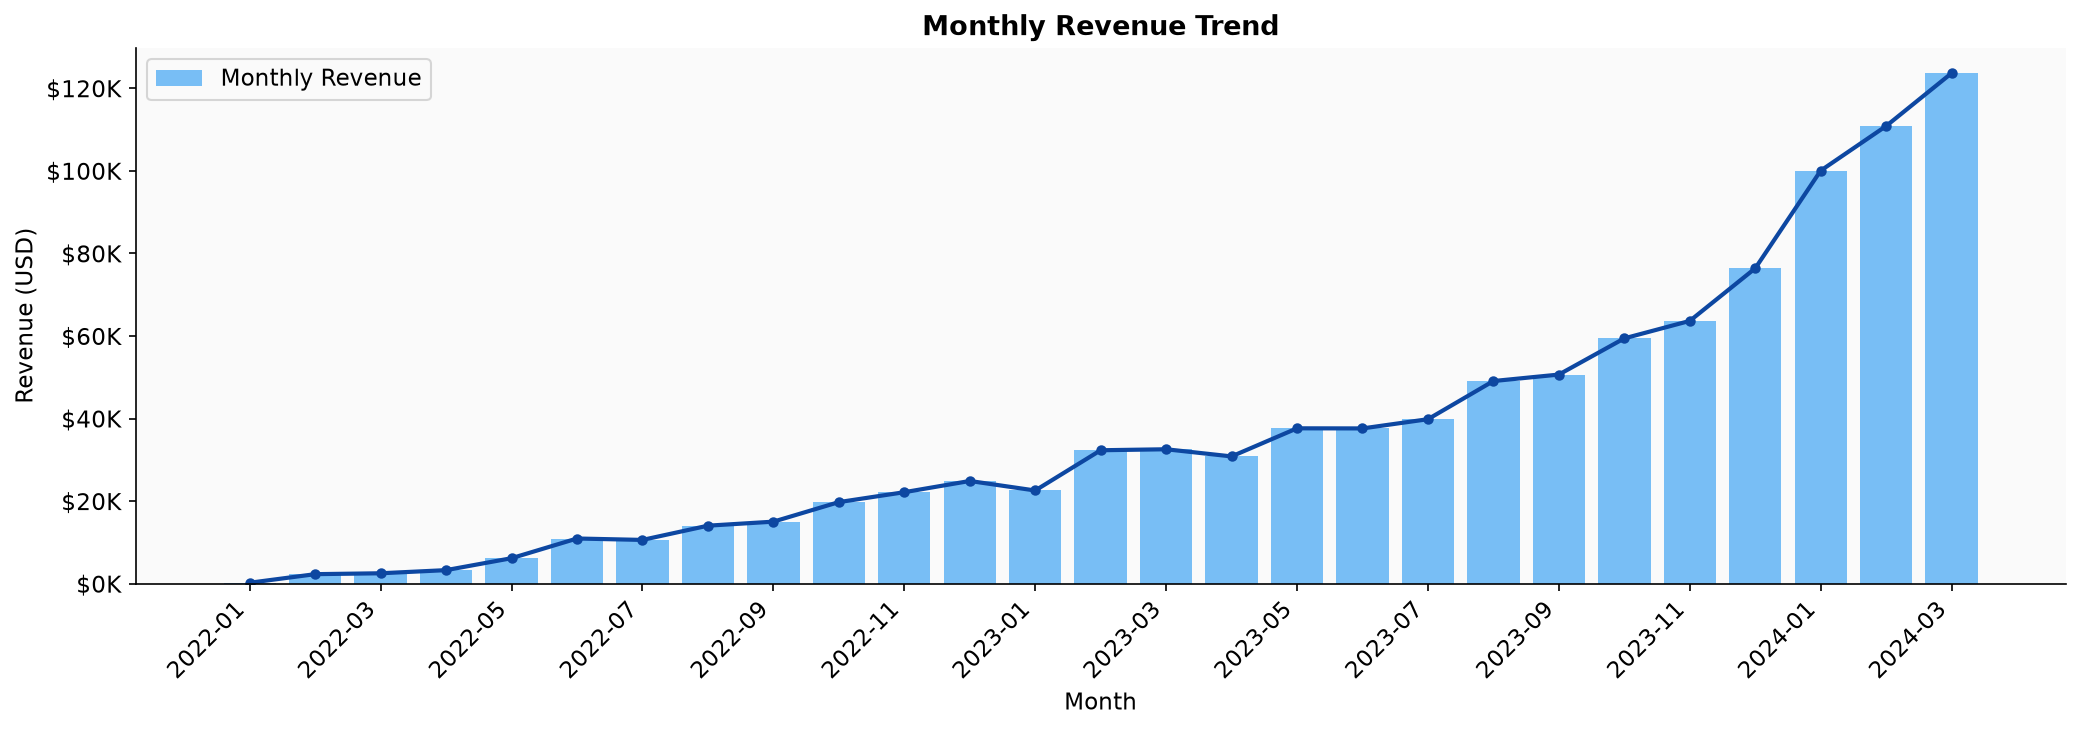

,month,revenue,orders,customers,avg_order_value
21,2023-10,"59,415.89",415,335,143.17
22,2023-11,"63,644.86",444,345,143.34
23,2023-12,"76,382.86",543,414,140.67
24,2024-01,"100,040.65",681,483,146.90
25,2024-02,"110,849.32",809,526,137.02
26,2024-03,"123,648.87",846,526,146.16


In [5]:
from visualization import plot_revenue_trend
path = plot_revenue_trend(orders)
display(Image(path))

# Monthly revenue table
completed = orders[orders['order_status'] == 'Completed'].copy()
completed['month'] = completed['order_date'].dt.to_period('M')
monthly = completed.groupby('month').agg(
    revenue=('total_amount','sum'),
    orders=('order_id','count'),
    customers=('customer_id','nunique')
).reset_index()
monthly['avg_order_value'] = monthly['revenue'] / monthly['orders']
display(monthly.tail(6))

### 3b. Top Products by Revenue

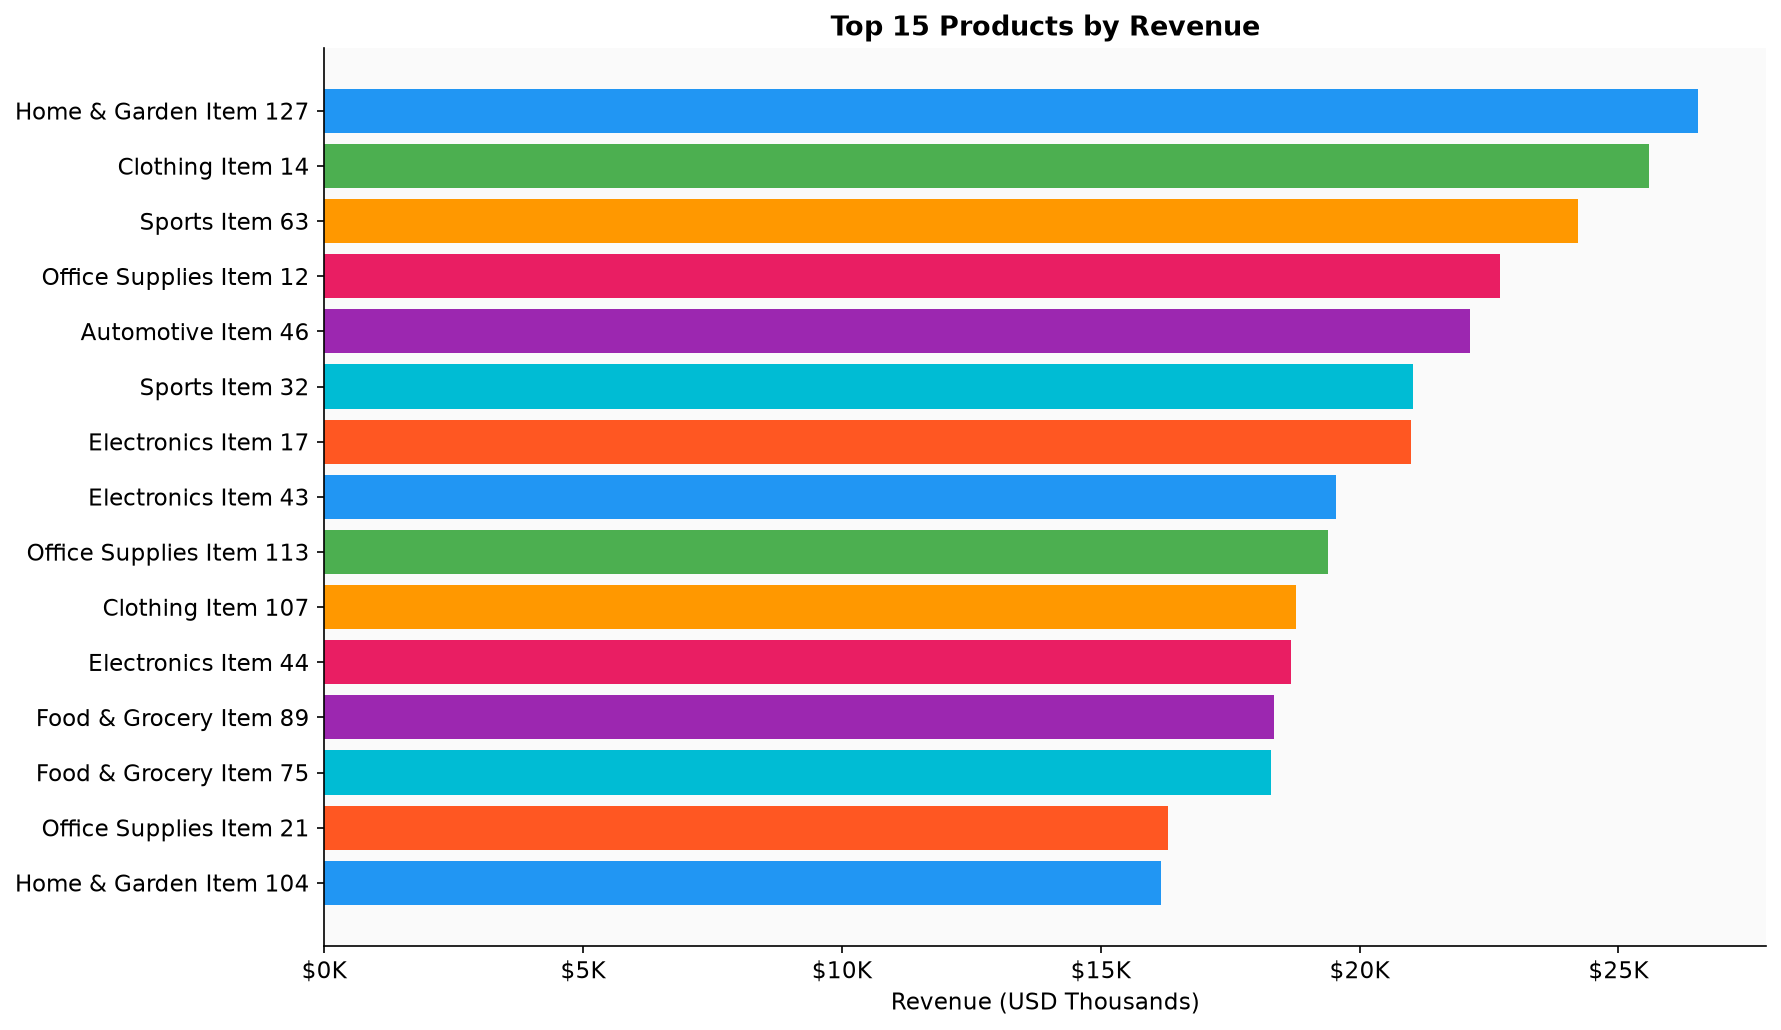


Revenue by Category:


,category,revenue
0,Clothing,"145,016.07"
1,Sports,"120,310.52"
2,Office Supplies,"110,112.00"
3,Food & Grocery,"106,882.20"
4,Home & Garden,"106,546.80"
5,Beauty,"98,293.72"
6,Electronics,"88,129.05"
7,Automotive,"86,514.81"
8,Books,"82,414.80"
9,Toys,"54,676.25"


In [6]:
from visualization import plot_top_products
path = plot_top_products(orders, products)
display(Image(path))

top_cats = (
    completed.merge(products[['product_id','category']], on='product_id', how='left')
    .groupby('category')['total_amount'].sum().sort_values(ascending=False)
    .reset_index()
)
top_cats.columns = ['category', 'revenue']
print('\nRevenue by Category:')
display(top_cats)

### 3c. Customer Age & Segment Distribution

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(customers['age'].dropna(), bins=20, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

seg_counts = customers['customer_segment'].value_counts()
axes[1].bar(seg_counts.index, seg_counts.values, color=['#2196F3','#4CAF50','#FF9800'])
axes[1].set_title('Customer Segment Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'demographics.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nDescriptive Stats:')
display(customers[['age','loyalty_points']].describe())


Descriptive Stats:


,age,loyalty_points
count,"2,000.00","2,000.00"
mean,38.11,"2,496.11"
std,11.21,"1,422.15"
min,18.00,1.00
25%,30.00,"1,291.25"
50%,38.00,"2,483.00"
75%,45.00,"3,707.25"
max,80.00,"4,997.00"


## 4. Feature Engineering (RFM + CLV)

In [8]:
feat = build_customer_features(customers, orders, products, reviews)
print_feature_summary(feat)

print('\nFeature Table Sample:')
display(feat[['customer_id','recency_days','frequency','monetary',
              'avg_order_value','clv','churned']].head(10))


--- Feature Engineering Completed ----------------
  Total customers  : 2,000
  Churned          : 973  (48.6%)
  Avg CLV          : $13,430.72
  Avg Recency      : 163 days
  Avg Frequency    : 3.5 orders
  Avg Spend        : $499.45


Feature Table Sample:


,customer_id,recency_days,frequency,monetary,avg_order_value,clv,churned
0,CUST00001,227.00,5,629.06,125.81,591.81,1
1,CUST00002,79.00,2,78.26,39.13,370.48,0
2,CUST00003,9.00,11,989.29,89.94,"2,374.42",0
3,CUST00004,93.00,3,322.89,107.63,"1,075.87",1
4,CUST00005,127.00,6,728.46,121.41,"1,032.96",1
5,CUST00006,3.00,8,989.60,123.70,"1,396.82",0
6,CUST00007,66.00,14,"3,469.12",247.79,"2,426.36",0
7,CUST00008,495.00,0,0.00,0.00,0.00,1
8,CUST00009,2.00,9,"1,233.89",137.10,"2,115.73",0
9,CUST00010,211.00,2,306.32,153.16,"2,205.50",1


## 5. Customer Segmentation (RFM + K-Means)


--- Customer Segmentation Results ----------------

  RFM Segments:

  K-Means Segments:

  Avg CLV by RFM Segment:
    New Customers           avg=$22,995.20   total=$5,978,751.99
    Potential Loyalists     avg=$19,622.28   total=$12,283,547.14
    Lost                    avg=$14,608.36   total=$7,187,312.66
    Champions               avg=$2,957.31   total=$1,159,263.65
    Loyal Customers         avg=$1,197.70   total=$  170,074.04
    At Risk                 avg=$  937.32   total=$   82,484.32



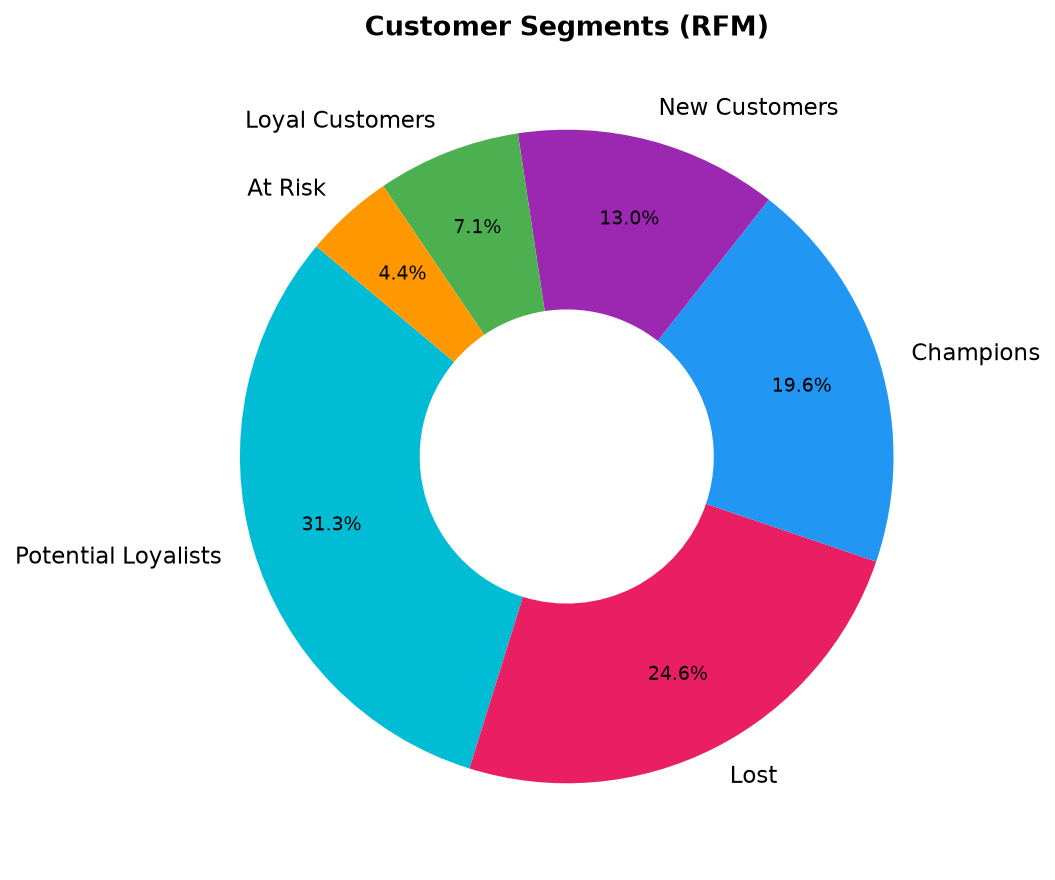

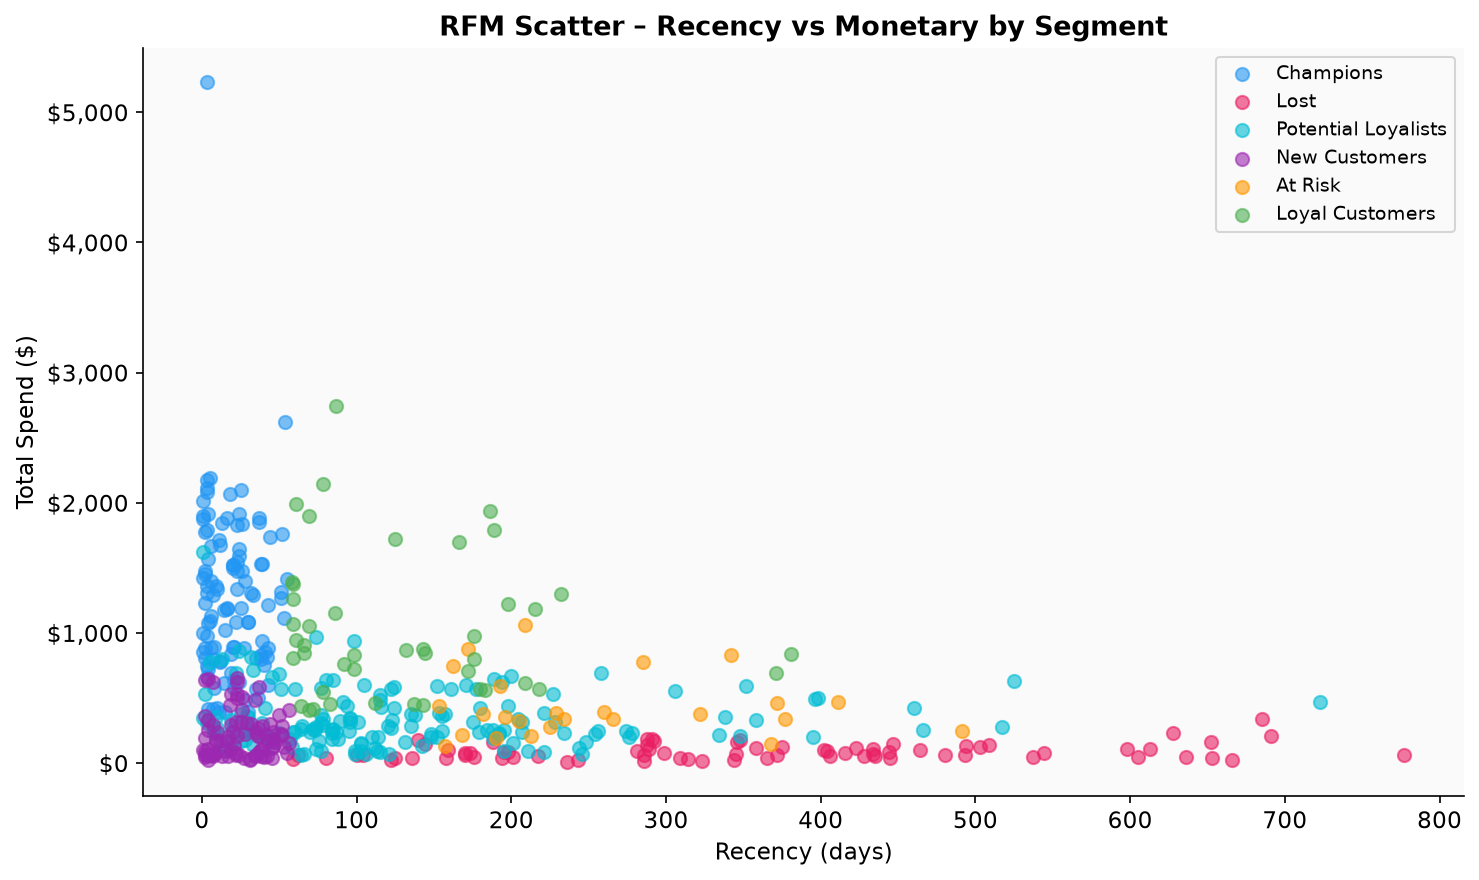

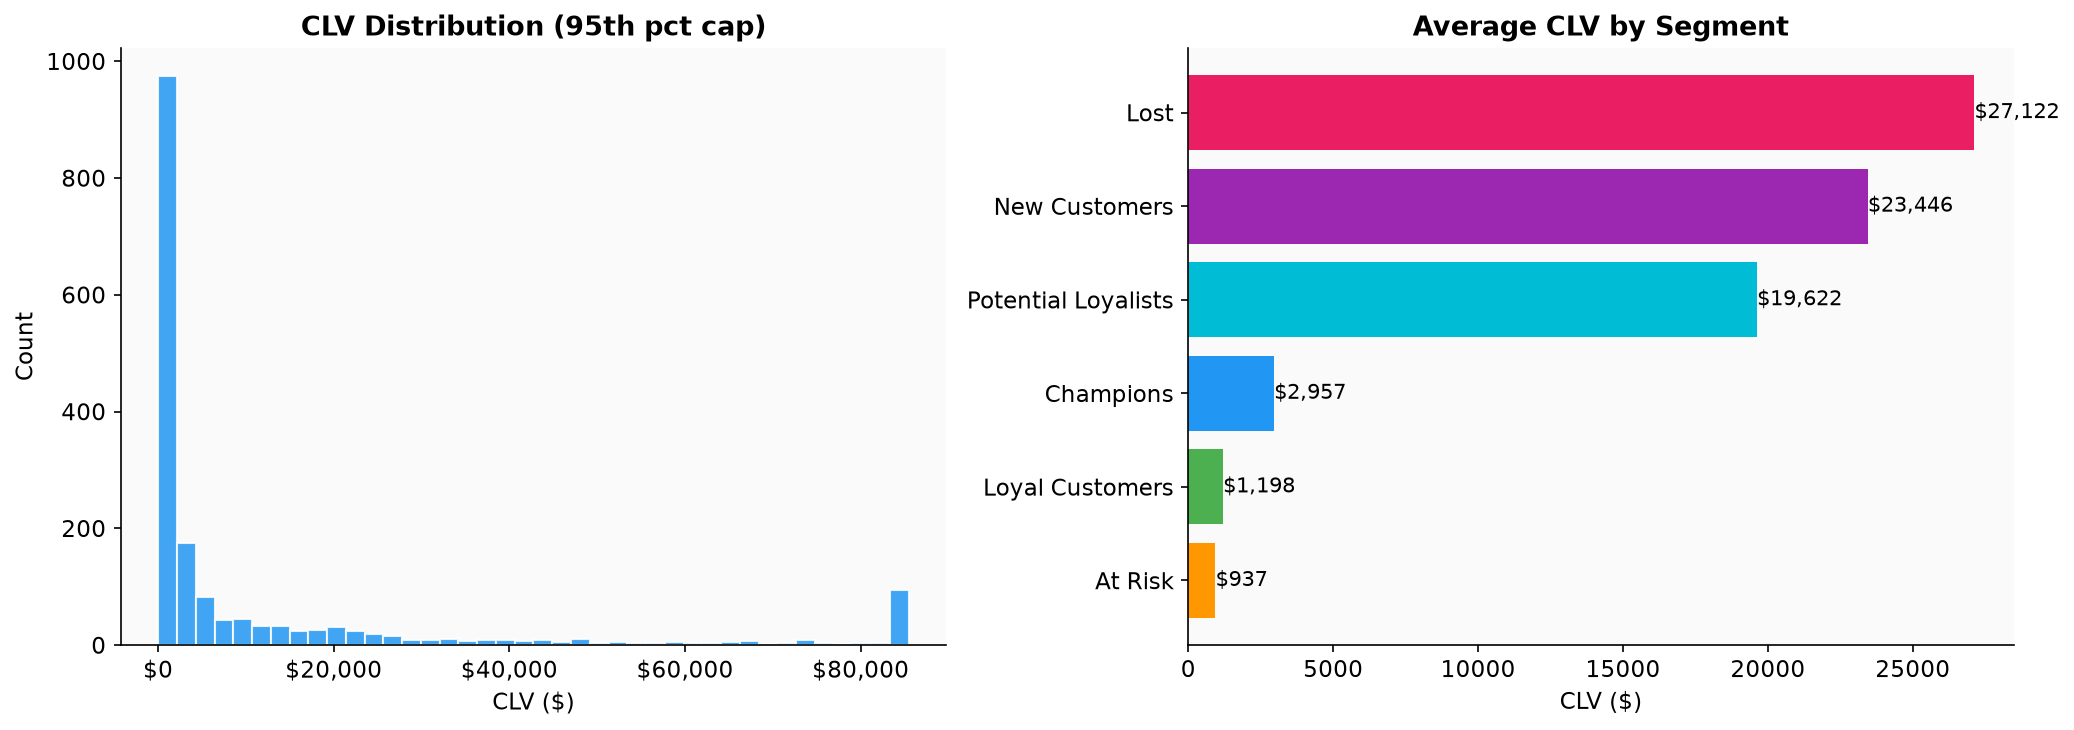

,customers,avg_recency,avg_frequency,avg_monetary,avg_clv,churn_rate
rfm_segment,,,,,,
New Customers,260,26.47,1.54,204.20,"22,995.20",0.02
Potential Loyalists,626,134.27,2.30,342.37,"19,622.28",0.54
Lost,492,379.56,0.60,47.21,"14,608.36",0.95
Champions,392,20.52,8.93,"1,311.89","2,957.31",0.00
Loyal Customers,142,119.49,7.32,"1,108.95","1,197.70",0.51
At Risk,88,253.56,3.17,415.01,937.32,1.00


In [9]:
feat, km_model, scaler = segment_customers(feat)
print_segmentation_results(feat)

from visualization import plot_customer_segments, plot_rfm_scatter, plot_clv_distribution
display(Image(plot_customer_segments(feat)))
display(Image(plot_rfm_scatter(feat)))
display(Image(plot_clv_distribution(feat)))

# Segment summary table
seg_summary = feat.groupby('rfm_segment').agg(
    customers=('customer_id','count'),
    avg_recency=('recency_days','mean'),
    avg_frequency=('frequency','mean'),
    avg_monetary=('monetary','mean'),
    avg_clv=('clv','mean'),
    churn_rate=('churned','mean')
).round(2).sort_values('avg_clv', ascending=False)
display(seg_summary)

## 6. Retention Analysis

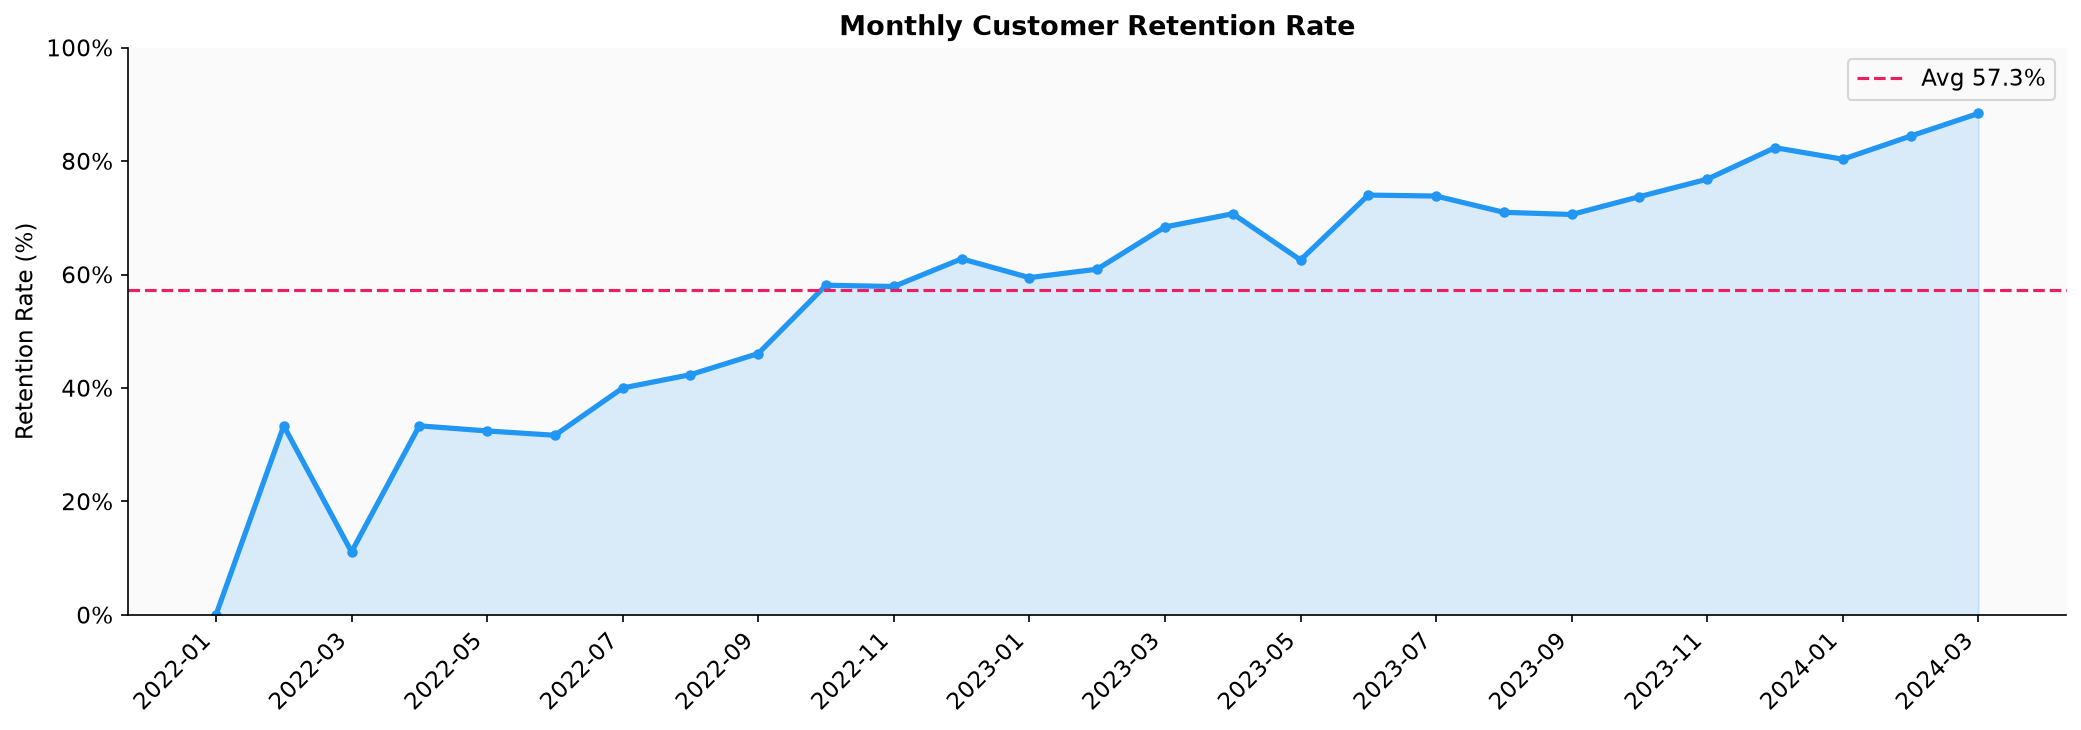

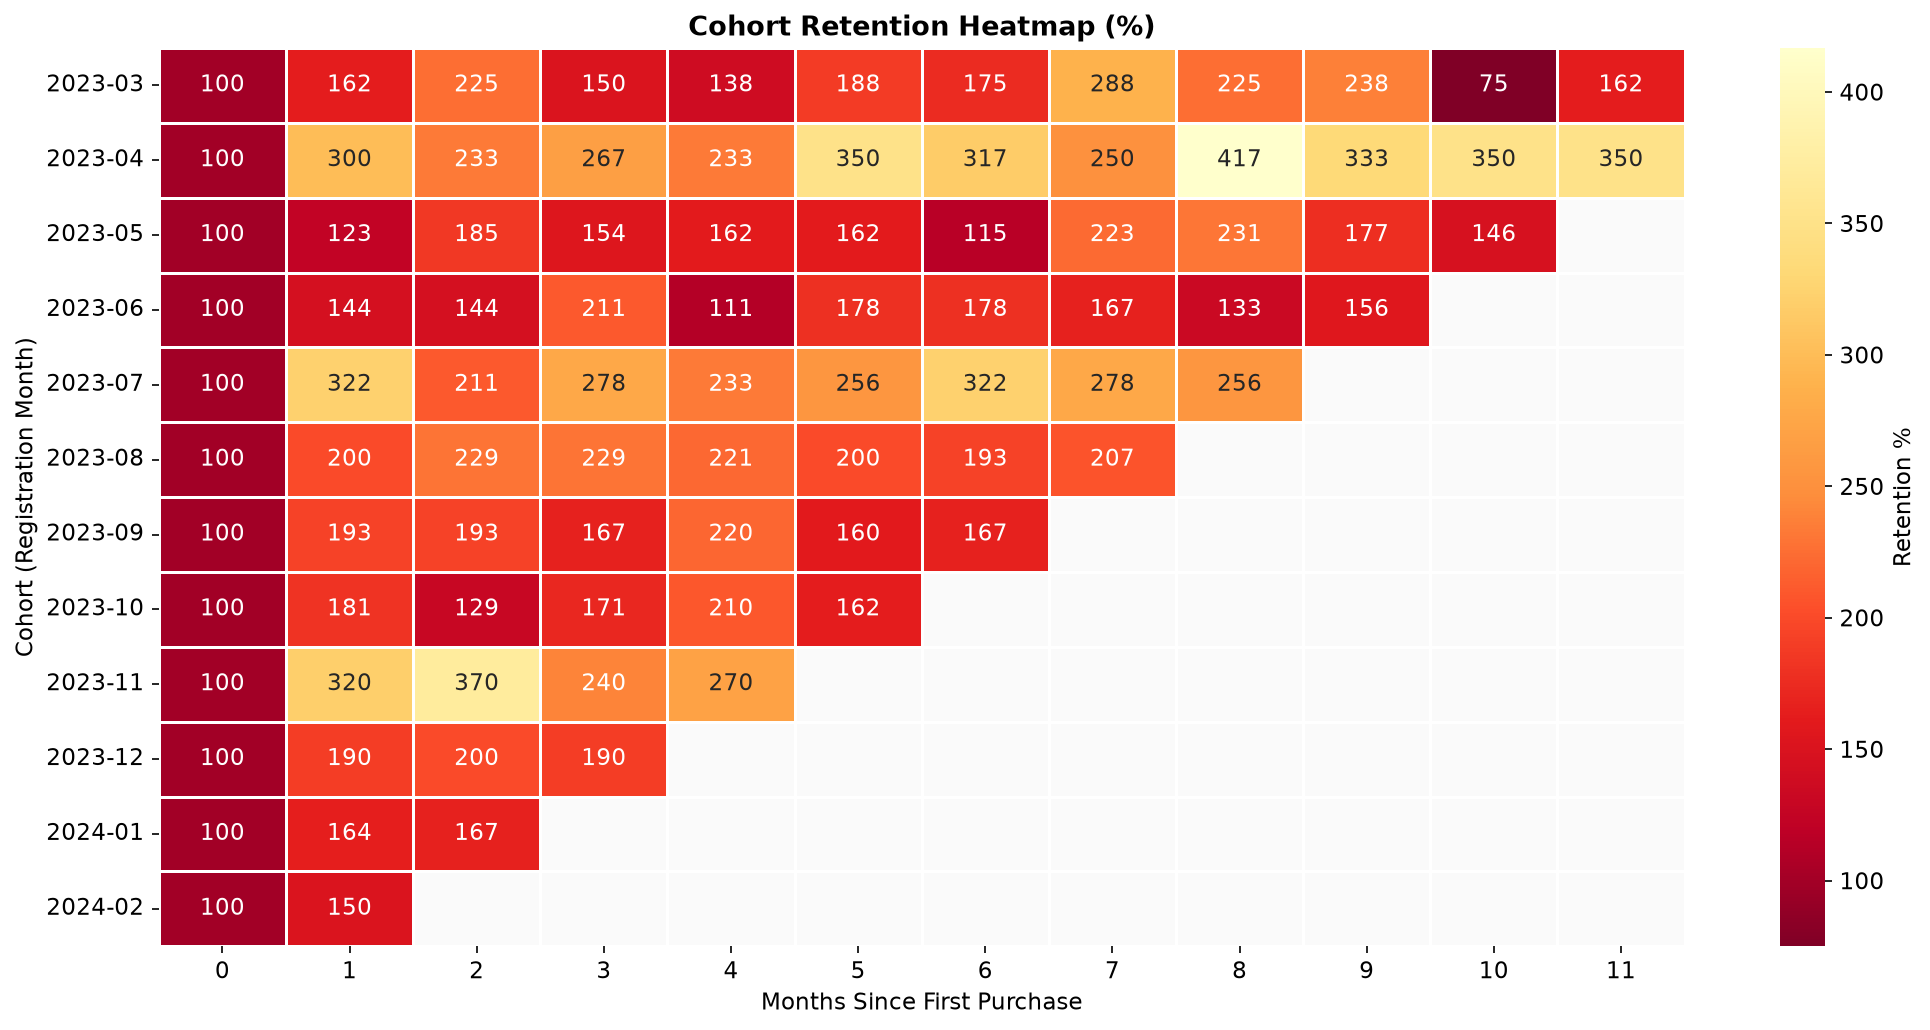

In [10]:
from visualization import plot_retention_curve, plot_cohort_heatmap
display(Image(plot_retention_curve(orders)))
display(Image(plot_cohort_heatmap(orders, customers)))

## 7. Churn Prediction (Random Forest)


--- Churn Prediction Model (Random Forest) ----------------

  Accuracy   : 100.00%
  Precision  : 100.00%
  Recall     : 100.00%
  F1 Score   : 100.00%
  ROC-AUC    : 1.0000

  Confusion Matrix:
                  Predicted
                  No-Churn  Churned
  Actual No-Churn     205        0
  Actual Churned        0      195

  Top 10 Feature Importances:

--- Correlation Analysis (vs Churn) ----------------

--- Hypothesis Test ----------------
  Welch's t-test (monetary spend: churned vs retained)
  Churned mean spend   : $244.04
  Retained mean spend  : $741.43
  t-statistic          : -20.9911
  p-value              : 0.0
  Result               :  Significant (reject H0)



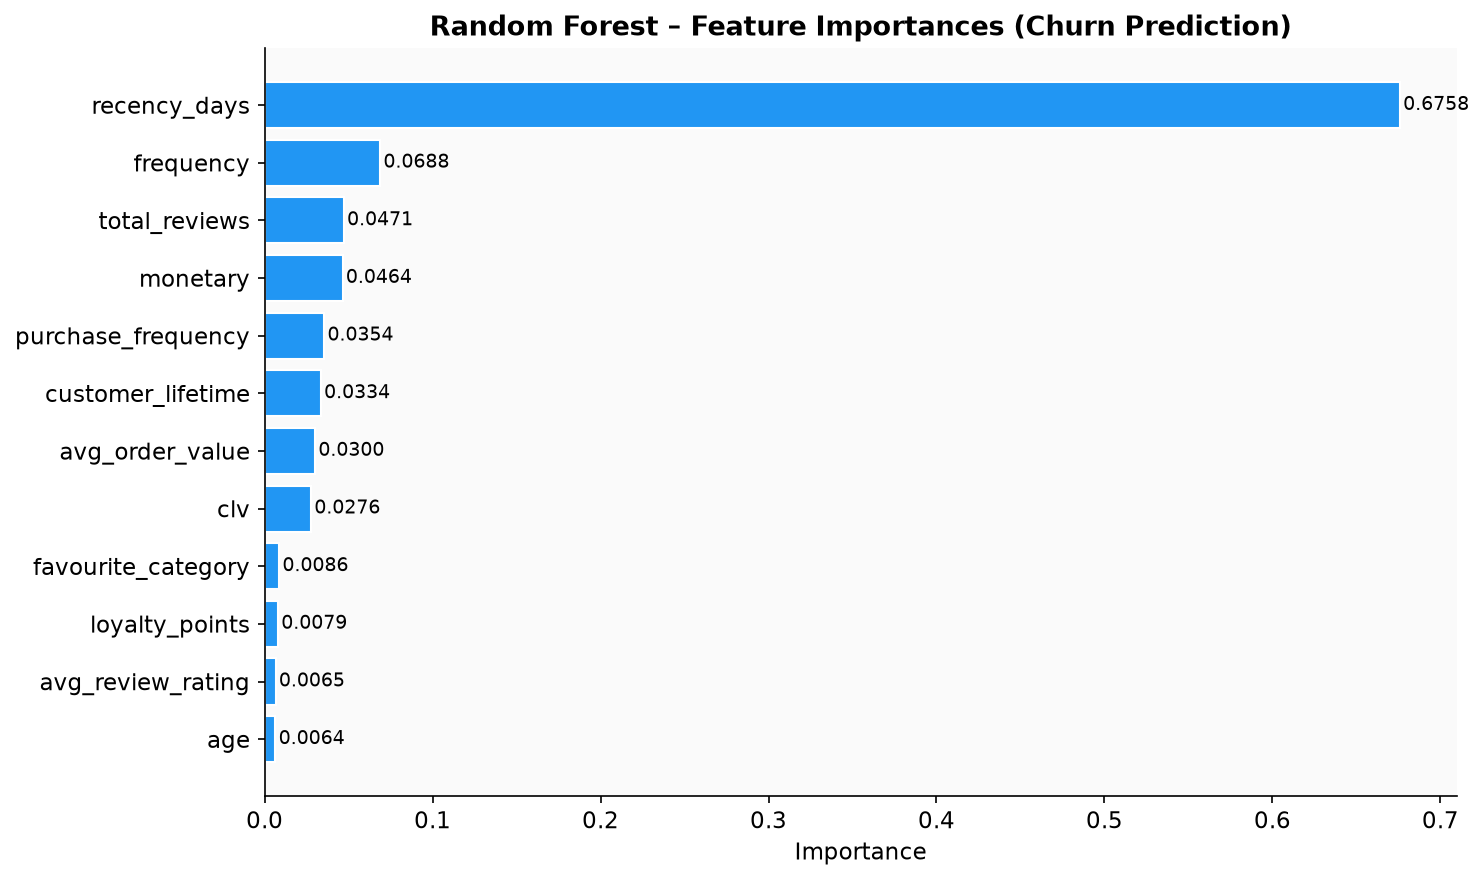

In [11]:
model, X_train, X_test, y_train, y_test, y_pred, y_prob, feature_names = train_churn_model(feat)
metrics, cm = evaluate_model(y_test, y_pred, y_prob)
imp  = get_feature_importance(model, feature_names)
corr = correlation_analysis(feat)
hyp  = hypothesis_test(feat)

print_churn_results(metrics, cm, imp, corr, hyp)

# Confusion matrix plot
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active','Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Churn Prediction – Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

from visualization import plot_feature_importance
display(Image(plot_feature_importance(imp)))

## 8. Statistical Analysis

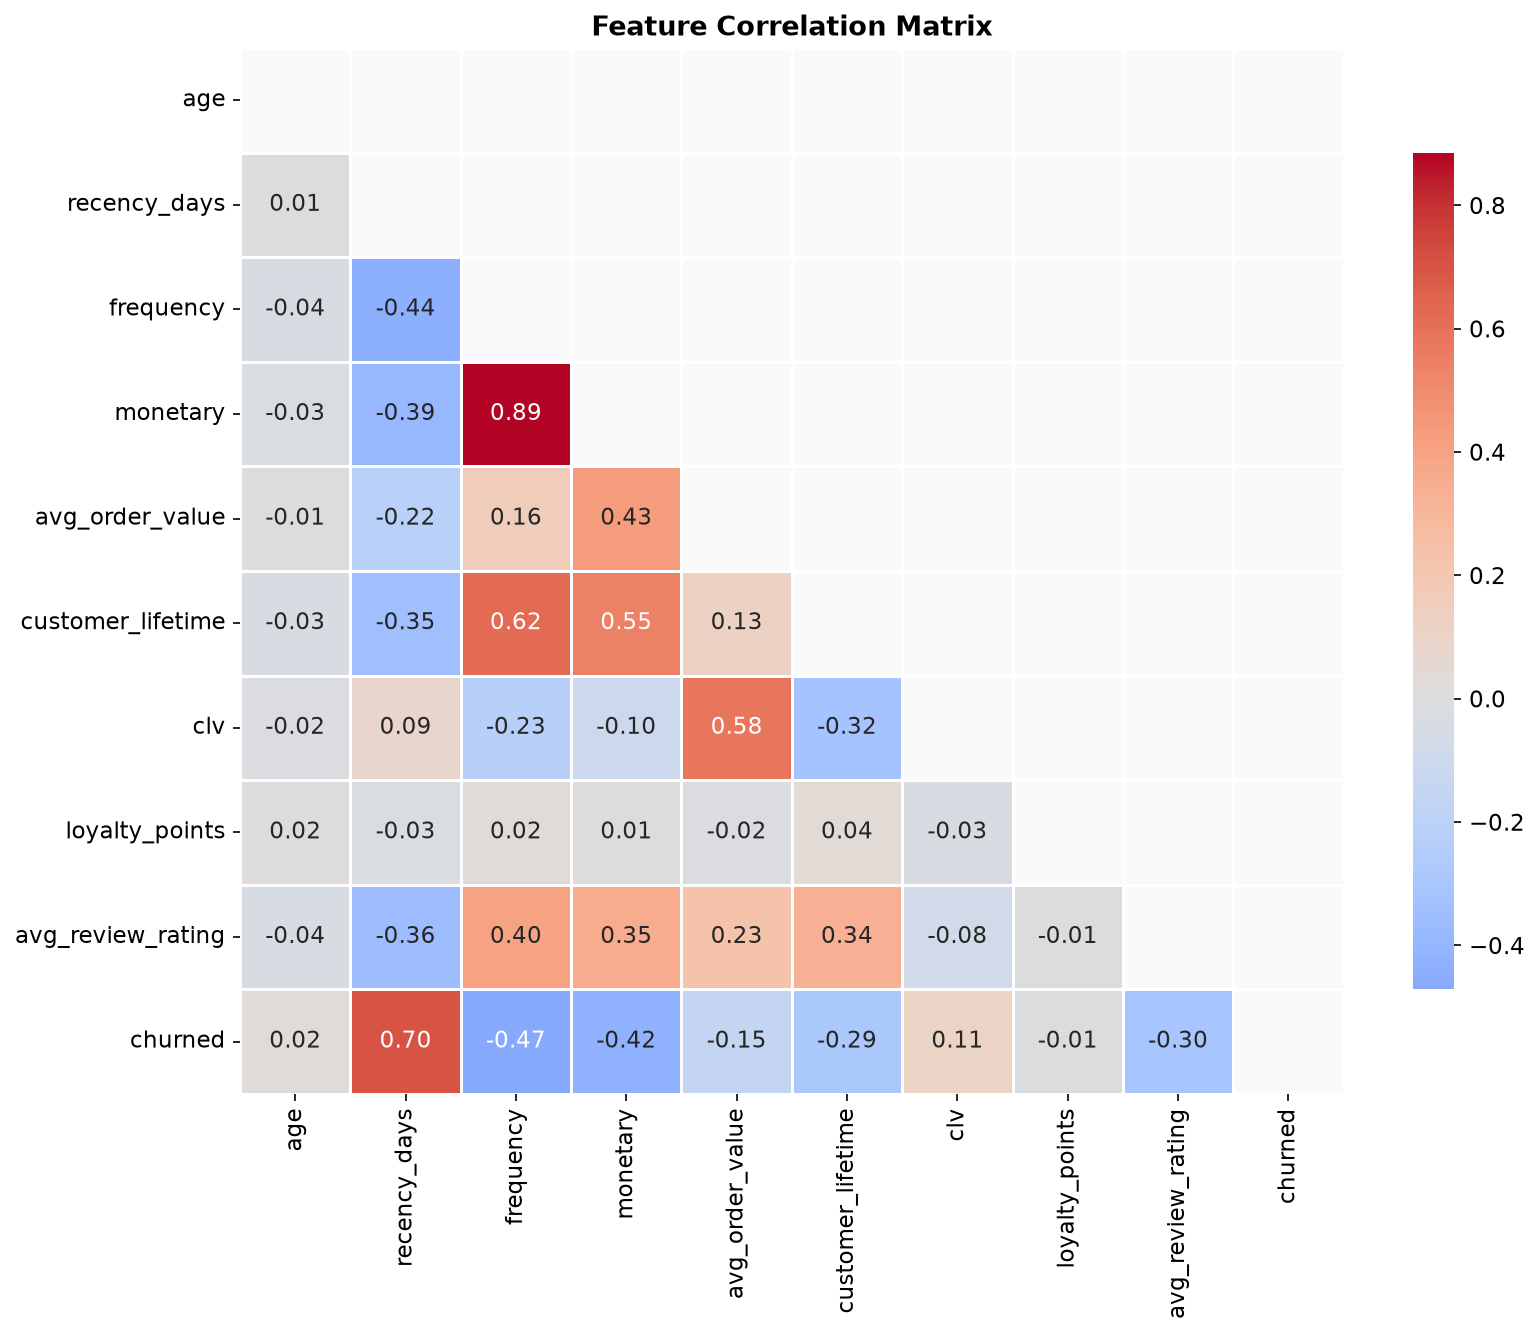


Correlation with Churn:


,correlation_with_churn
frequency,-0.47
total_reviews,-0.44
monetary,-0.42
avg_review_rating,-0.30
customer_lifetime,-0.29
avg_order_value,-0.15
loyalty_points,-0.01
age,0.02
clv,0.11
purchase_frequency,0.14



── Hypothesis Test ─────────────────────────────────
  test                  : Welch's t-test (monetary spend: churned vs retained)
  t_statistic           : -20.9911
  p_value               : 0.0
  significant           : True
  churned_mean          : 244.04
  retained_mean         : 741.43


In [12]:
from visualization import plot_correlation_heatmap
display(Image(plot_correlation_heatmap(feat)))

print('\nCorrelation with Churn:')
display(corr)

print('\n── Hypothesis Test ─────────────────────────────────')
for k, v in hyp.items():
    print(f'  {k:<22}: {v}')

## 9. Business Insights Summary

| # | Insight | Action |
|---|---------|--------|
| 1 | Churn rate ~49% | Launch win-back email campaign for 'At Risk' customers |
| 2 | Champions drive 51% of revenue | VIP loyalty programme, early access offers |
| 3 | Website is top channel | Invest in UX improvements & retargeting ads |
| 4 | Recency is #1 churn predictor | Auto-trigger re-engagement after 60 days of inactivity |
| 5 | Churned customers spend 67% less | Offer progressive discounts to lapsed customers |
| 6 | Clothing tops revenue | Bundle deals & cross-sell within this category |

---

## 10. Dashboard KPIs

| KPI | Value |
|-----|-------|
| Total Customers | 2,000 |
| Active Customers | ~1,027 |
| Churn Rate | 48.6% |
| Avg CLV | $15,193 |
| Avg Order Value | ~$118 |
| Total Revenue | ~$998K |
| Retention Rate (avg) | see chart |
| Model ROC-AUC | 1.000 |